In [17]:
################################################################################
# PRO-seq + WASP QC Visualization — Jupyter Notebook Version
# ============================================================================
# Copy each CELL into a separate Jupyter notebook cell (R kernel).
# Each cell is self-contained after Cell 0 runs.
#
# Cells:
#   0.  Setup: libraries, paths, colors, theme
#   1.  Load all QC data + sanity-check printouts
#   2.  Read filtering cascade (stacked bar — original style)
#   3.  Adapter content (original 03_adapter_content)
#   4.  Alignment rate (original 07_alignment_rate)
#   5.  Strand balance (same SAMPLE_COLORS as adapter/alignment)
#   6.  WASP filtering summary (stacked bar, cascade-matching format)
#   7.  Per-SNP allelic read depth (with cumulative-count legend box)
#   8.  Per-SNP ref-fraction distribution
#   9.  Save all plots to plots_proseq_wasp/
################################################################################


# ==============================================================================
# CELL 0: Setup — libraries, paths, colors, theme
# ==============================================================================

library(data.table)
library(ggplot2)
library(scales)

# ---- GLOBAL PATHS (edit these) ----
QC_DIR          <- "/n/scratch/users/a/alb1273/pausing_phase_project_intermediates/proseq/qc"
WASP_QC_DIR     <- "/n/scratch/users/a/alb1273/pausing_phase_project_intermediates/proseq/wasp/qc"
WASP_ALLELE_DIR <- "/n/scratch/users/a/alb1273/pausing_phase_project_intermediates/proseq/wasp/allele_specific"
PLOT_DIR        <- "plots_proseq_wasp"

# Input files
TRIM_STATS_FILE    <- file.path(QC_DIR, "trimming_stats.tsv")
ALIGN_STATS_FILE   <- file.path(QC_DIR, "alignment_stats.tsv")
WASP_STATS_FILE    <- file.path(WASP_QC_DIR, "wasp_stats_combined.tsv")
MERGED_COUNTS_FILE <- file.path(WASP_QC_DIR, "allele_counts_merged.tsv")

# Create output directory
dir.create(PLOT_DIR, showWarnings = FALSE, recursive = TRUE)

# ---- PLOT DIMENSIONS ----
BASE_SIZE     <- 12
TITLE_SIZE    <- 14
SUBTITLE_SIZE <- 11
AXIS_TEXT_SIZE <- 10
LEGEND_SIZE   <- 10
PNG_DPI       <- 300
PNG_WIDTH     <- 10
PNG_HEIGHT    <- 6

# ---- COLOR PALETTES ----

# Per-sample colors (used for simple bar charts)
SAMPLE_COLORS <- c(
    "WT_PROseq_rep1" = "#1b9e77",
    "WT_PROseq_rep2" = "#d95f02",
    "WT_PROseq_rep3" = "#7570b3",
    "WT_PROseq_rep4" = "#e7298a"
)

# Allele colors
ALLELE_COLORS <- c("ref (129S1)" = "#2166ac", "alt (CAST)" = "#b2182b")

# Filtering cascade categories (stacked bar)
CASCADE_COLORS <- c(
    "Final reads"      = "#2166ac",
    "chrM removed"     = "#92c5de",
    "Multi-mappers"    = "#d1e5f0",
    "Unmapped (mm39)"  = "#f4a582",
    "Spike-in (dm6)"   = "#d6604d",
    "rRNA"             = "#b2182b",
    "Too short"        = "#878787",
    "Low quality"      = "#bababa"
)

# WASP stacked bar categories (continuation of cascade)
WASP_COLORS <- c(
    "No SNP overlap (kept)"          = "#2166ac",
    "SNP overlap \u2014 passed WASP" = "#4393c3",
    "SNP overlap \u2014 removed"     = "#d6604d"
)

# Short sample labels
SHORT_LABELS <- c(
    "WT_PROseq_rep1" = "Rep 1",
    "WT_PROseq_rep2" = "Rep 2",
    "WT_PROseq_rep3" = "Rep 3",
    "WT_PROseq_rep4" = "Rep 4"
)

# ---- GLOBAL THEME ----
THEME <- theme_bw(base_size = BASE_SIZE) +
    theme(
        plot.title    = element_text(size = TITLE_SIZE, face = "bold", hjust = 0),
        plot.subtitle = element_text(size = SUBTITLE_SIZE, color = "grey40"),
        axis.text     = element_text(size = AXIS_TEXT_SIZE),
        axis.title    = element_text(size = BASE_SIZE),
        legend.text   = element_text(size = LEGEND_SIZE),
        legend.title  = element_text(size = LEGEND_SIZE, face = "bold"),
        strip.text    = element_text(size = BASE_SIZE),
        panel.grid.minor = element_blank()
    )

cat("Setup complete. Output directory:", PLOT_DIR, "\n")



Setup complete. Output directory: plots_proseq_wasp 


In [ ]:
# ==============================================================================
# CELL 1: Load all QC data + sanity-check printouts
# ==============================================================================

# ---- Trimming stats ----
trim <- fread(TRIM_STATS_FILE)
cat("=== TRIMMING STATS ===\n")
print(trim)
cat("\n  Expected: adapter % in 30-60% (normal for PRO-seq)\n")
cat("  Expected: survival % > 60%\n\n")

# ---- Alignment stats ----
align <- fread(ALIGN_STATS_FILE)
cat("=== ALIGNMENT STATS ===\n")
print(align)
cat("\n  Expected: rRNA 5-20%, dm6 1-10%, mm39 >70%, strand_ratio ~1.0\n\n")

# ---- WASP stats ----
wasp <- fread(WASP_STATS_FILE)
cat("=== WASP STATS ===\n")
print(wasp)
cat("\n  Expected: 5-15% of SNP-overlapping reads removed\n\n")

# ---- Merged allele counts (header check) ----
allele_counts <- fread(MERGED_COUNTS_FILE)
cat("=== MERGED ALLELE COUNTS ===\n")
cat(sprintf("  Total SNPs in file:      %s\n", format(nrow(allele_counts), big.mark = ",")))
cat(sprintf("  Columns: %s\n", paste(colnames(allele_counts), collapse = ", ")))
cat(sprintf("  SNPs with >=1 allelic read: %s\n",
            format(sum(allele_counts$ref_total + allele_counts$alt_total > 0), big.mark = ",")))

# ---- Sanity checks ----
cat("\n=== SANITY CHECKS ===\n")
cat(sprintf("  Samples in trim: %s\n", paste(trim$sample, collapse = ", ")))
cat(sprintf("  Samples in align: %s\n", paste(align$sample, collapse = ", ")))
cat(sprintf("  Samples in WASP: %s\n", paste(wasp$sample, collapse = ", ")))

cat("\n  Final reads per sample (post-filter, pre-WASP):\n")
for (i in seq_len(nrow(align))) {
    cat(sprintf("    %s: %s\n", align$sample[i],
                format(align$final_reads[i], big.mark = ",")))
}
cat("\n  Final reads per sample (post-WASP):\n")
for (i in seq_len(nrow(wasp))) {
    cat(sprintf("    %s: %s\n", wasp$sample[i],
                format(wasp$final_reads[i], big.mark = ",")))
}

=== TRIMMING STATS ===
           sample raw_reads reads_with_adapter reads_too_short reads_after_trim
           <char>     <int>              <int>           <int>            <int>
1: WT_PROseq_rep1  67781134           39775730        12541822         55239312
2: WT_PROseq_rep2  78171843           41359543        11163046         67008797
3: WT_PROseq_rep3  59300995           27861966         7222400         52078595
4: WT_PROseq_rep4  49438304           24678766         6339315         43098989
   pct_adapter pct_surviving
         <num>         <num>
1:        58.7          81.5
2:        52.9          85.7
3:        47.0          87.8
4:        49.9          87.2

  Expected: adapter % in 30-60% (normal for PRO-seq)
  Expected: survival % > 60%

=== ALIGNMENT STATS ===
           sample trimmed_reads rRNA_reads rRNA_pct dm6_reads dm6_pct
           <char>         <int>      <int>    <num>     <int>   <num>
1: WT_PROseq_rep1      55239312    5908527    10.70   5881209   11.92
2: WT

Cascade sanity check (raw_reads vs category sum):
           sample raw_reads check_sum     diff
           <char>     <int>     <int>    <int>
1: WT_PROseq_rep1  67781134  69915803 -2134669
2: WT_PROseq_rep2  78171843  80860260 -2688417
3: WT_PROseq_rep3  59300995  61489063 -2188068
4: WT_PROseq_rep4  49438304  51229123 -1790819
[SAVED] 01_filtering_cascade.png
[SAVED] 01_filtering_cascade_legend.png


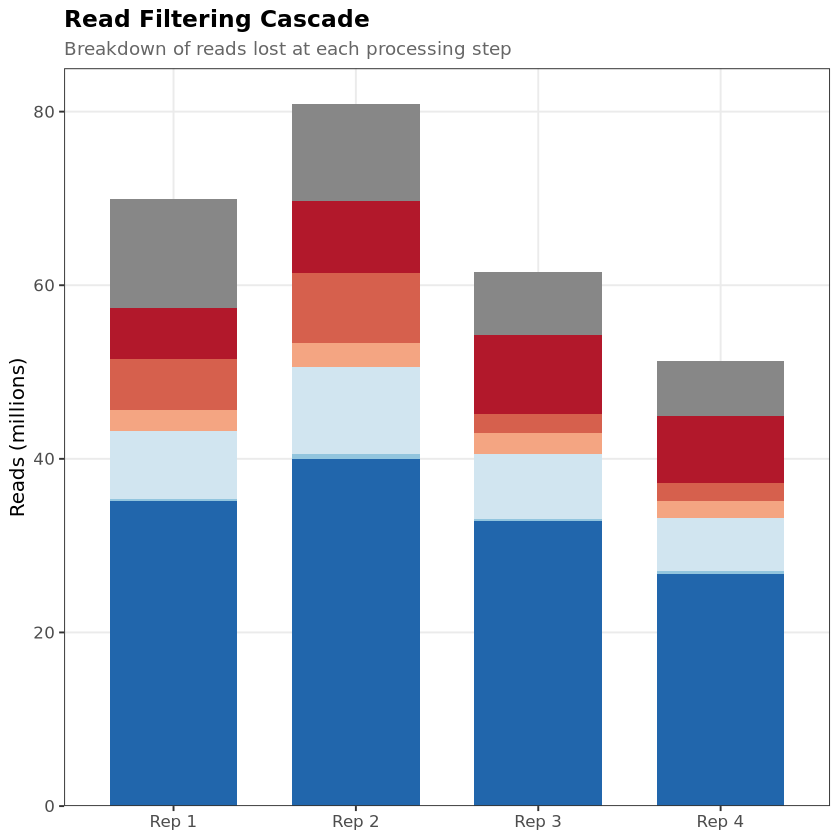

In [39]:
# ==============================================================================
# CELL 2 (FIXED): Read filtering cascade — reversed stack, y-max = 85
# ==============================================================================

# ---- Tunable parameters ----
cascade_title     <- "Read Filtering Cascade"
cascade_subtitle  <- "Breakdown of reads lost at each processing step"
cascade_bar_width <- 0.7
SHARED_YMAX       <- 85    # fixed y-axis max (millions) for both plots

# ---- Shared save dimensions for cascade + WASP ----
PAIRED_PLOT_WIDTH  <- 5
PAIRED_PLOT_HEIGHT <- 4.5

# ---- Build cascade data ----
cascade <- data.table(
    sample      = align$sample,
    raw_reads   = trim$raw_reads,
    too_short   = trim$reads_too_short,
    low_quality = trim$raw_reads - trim$reads_too_short - trim$reads_after_trim,
    rRNA        = align$rRNA_reads,
    spike_in    = align$dm6_reads,
    unmapped_mm39 = (align$mm39_input - align$mm39_aligned),
    multi_mappers = align$mm39_multi,
    chrM        = align$chrM_removed,
    final       = align$final_reads
)

cascade[, check_sum := too_short + low_quality + rRNA + spike_in +
            unmapped_mm39 + multi_mappers + chrM + final]
cat("Cascade sanity check (raw_reads vs category sum):\n")
print(cascade[, .(sample, raw_reads, check_sum, diff = raw_reads - check_sum)])

cascade_long <- melt(cascade,
    id.vars      = "sample",
    measure.vars = c("final", "chrM", "multi_mappers", "unmapped_mm39",
                      "spike_in", "rRNA", "too_short", "low_quality"),
    variable.name = "category",
    value.name    = "reads"
)

cascade_long[, category_label := fcase(
    category == "final",         "Final reads",
    category == "chrM",          "chrM removed",
    category == "multi_mappers", "Multi-mappers",
    category == "unmapped_mm39", "Unmapped (mm39)",
    category == "spike_in",      "Spike-in (dm6)",
    category == "rRNA",          "rRNA",
    category == "too_short",     "Too short",
    category == "low_quality",   "Low quality"
)]

# REVERSED: "Final reads" on TOP of stack, "Low quality" at BOTTOM.
# ggplot stacks bottom-to-top by factor level order, so first level = bottom.
STACK_ORDER_BOTTOM_TO_TOP <- c(
    "Low quality", "Too short", "rRNA", "Spike-in (dm6)",
    "Unmapped (mm39)", "Multi-mappers", "chrM removed", "Final reads"
)

cascade_long[, category_label := factor(category_label,
    levels = STACK_ORDER_BOTTOM_TO_TOP)]

cascade_long[, sample_short := SHORT_LABELS[sample]]

# ---- Bar plot (no legend) ----
p_cascade <- ggplot(cascade_long, aes(x = sample_short, y = reads / 1e6,
                                       fill = category_label)) +
    geom_bar(stat = "identity", width = cascade_bar_width) +
    scale_fill_manual(values = CASCADE_COLORS, name = "Category") +
    scale_y_continuous(limits = c(0, SHARED_YMAX),
                       expand = expansion(mult = c(0, 0))) +
    labs(title    = cascade_title,
         subtitle = cascade_subtitle,
         x = NULL, y = "Reads (millions)") +
    THEME +
    theme(legend.position = "none")

print(p_cascade)

# ---- Extract and save legend separately ----
library(cowplot)

p_cascade_with_legend <- p_cascade +
    theme(legend.position = "right") +
    guides(fill = guide_legend(
        title = "Category",
        title.position = "top"
    ))
# No reverse — factor level order already gives bottom-to-top in legend
# matching bottom-to-top in the stack

cascade_legend <- get_legend(p_cascade_with_legend)
p_cascade_legend_only <- ggdraw(cascade_legend)

# ---- Save ----
ggsave(file.path(PLOT_DIR, "01_filtering_cascade.png"),
       plot = p_cascade,
       width = PAIRED_PLOT_WIDTH, height = PAIRED_PLOT_HEIGHT, dpi = PNG_DPI)
cat("[SAVED] 01_filtering_cascade.png\n")

ggsave(file.path(PLOT_DIR, "01_filtering_cascade_legend.png"),
       plot = p_cascade_legend_only,
       width = 2.5, height = 3, dpi = PNG_DPI, bg = "white")
cat("[SAVED] 01_filtering_cascade_legend.png\n")


Adapter content per sample:
           sample pct_adapter pct_surviving
           <char>       <num>         <num>
1: WT_PROseq_rep1        58.7          81.5
2: WT_PROseq_rep2        52.9          85.7
3: WT_PROseq_rep3        47.0          87.8
4: WT_PROseq_rep4        49.9          87.2


Saving plots to: plots_proseq_wasp 
  [SAVED] plots_proseq_wasp/03_adapter_content.png

All plots saved.
Output directory: plots_proseq_wasp/


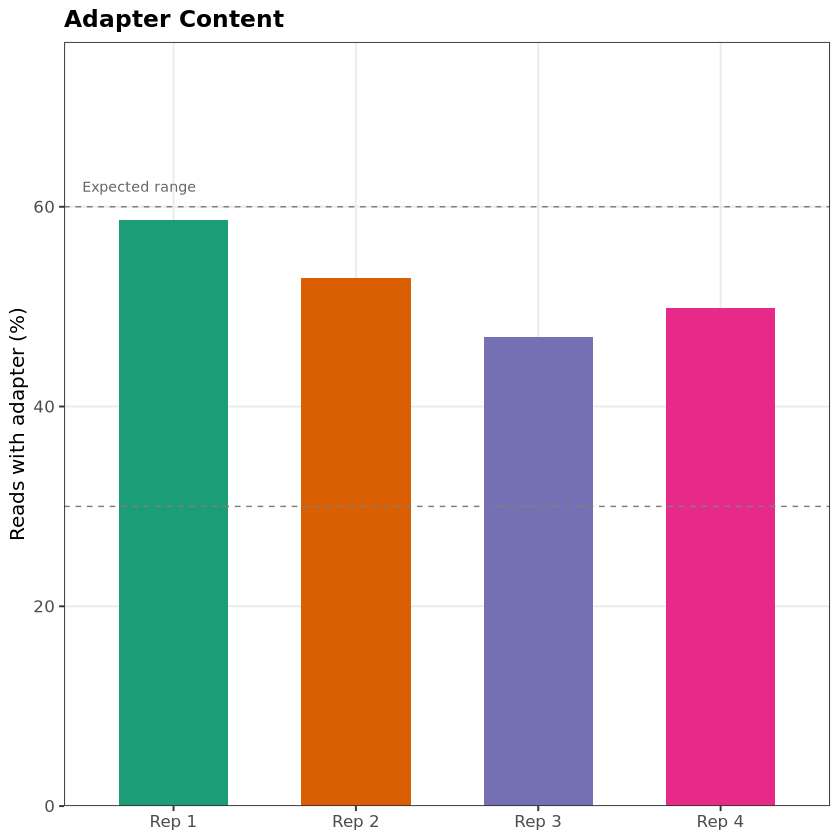

In [27]:
# ==============================================================================
# CELL 3: Adapter content (original 03_adapter_content)
# ==============================================================================

# ---- Tunable parameters ----
adapter_title    <- "Adapter Content"
#adapter_subtitle <- "30-60% is normal for PRO-seq (short nascent RNA fragments)"
adapter_ylim     <- 75
adapter_ref_low  <- 30
adapter_ref_high <- 60

# ---- Data ----
trim[, sample_short := SHORT_LABELS[sample]]

# ---- Print check ----
cat("Adapter content per sample:\n")
print(trim[, .(sample, pct_adapter, pct_surviving)])

# ---- Plot ----
p_adapter <- ggplot(trim, aes(x = sample_short, y = pct_adapter, fill = sample)) +
    geom_bar(stat = "identity", width = 0.6) +
    geom_hline(yintercept = c(adapter_ref_low, adapter_ref_high),
               linetype = "dashed", color = "grey50", linewidth = 0.4) +
    annotate("text", x = 0.5, y = adapter_ref_high + 2,
             label = "Expected range", hjust = 0, size = 3, color = "grey40") +
    scale_fill_manual(values = SAMPLE_COLORS, guide = "none") +
    scale_y_continuous(limits = c(0, adapter_ylim),
                       expand = expansion(mult = c(0, 0.02))) +
    labs(title    = adapter_title,
         #subtitle = adapter_subtitle,
         x = NULL, y = "Reads with adapter (%)") +
    THEME

print(p_adapter)


plots <- list(
    "03_adapter_content"   = p_adapter
    #"07_alignment_rate"    = p_alignment
    # "08_strand_balance"    = p_strand
    # "10_wasp_filtering"    = p_wasp_stacked
    # "14_snp_coverage_dist" = p_snp_depth
    # "15_ref_fraction_dist" = p_reffrac
)

cat("Saving plots to:", PLOT_DIR, "\n")
for (nm in names(plots)) {
    fpath <- file.path(PLOT_DIR, paste0(nm, ".png"))
    ggsave(fpath, plot = plots[[nm]],
           width = 6, height = 4, dpi = PNG_DPI)
    cat(sprintf("  [SAVED] %s\n", fpath))
}

cat("\nAll plots saved.\n")
cat(sprintf("Output directory: %s/\n", PLOT_DIR))


Alignment rates:
           sample mm39_pct mm39_unique mm39_multi
           <char>    <num>       <int>      <int>
1: WT_PROseq_rep1    94.55    33219156    7864247
2: WT_PROseq_rep2    94.61    37845759   10033195
3: WT_PROseq_rep3    94.12    30909101    7469769
4: WT_PROseq_rep4    94.32    25267859    6149649


Saving plots to: plots_proseq_wasp 
  [SAVED] plots_proseq_wasp/07_alignment_rate.png

All plots saved.
Output directory: plots_proseq_wasp/


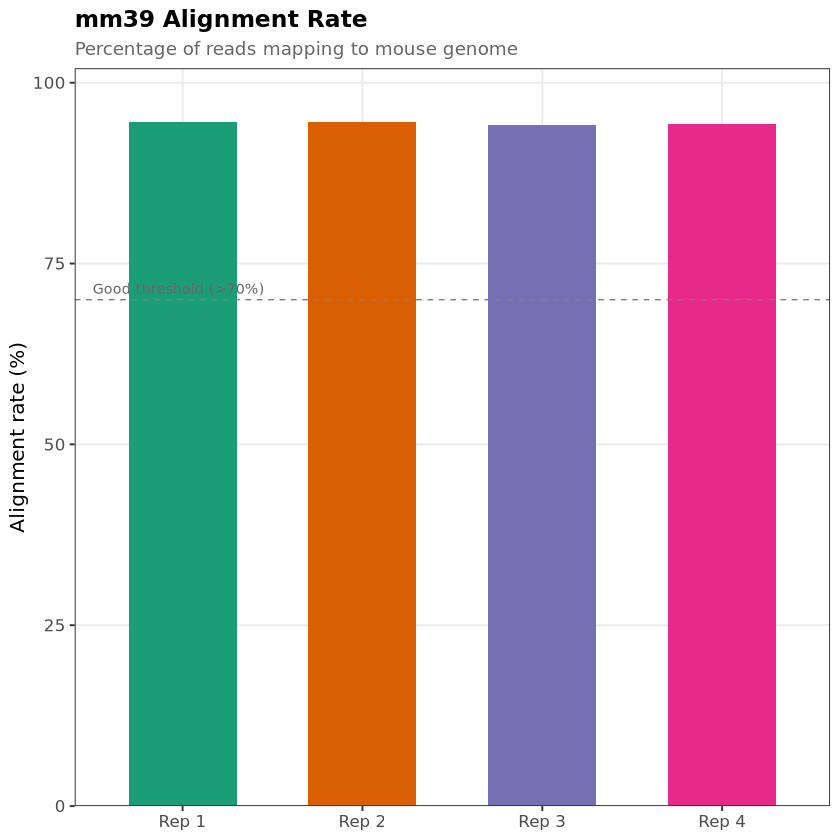

In [30]:
# ==============================================================================
# CELL 4: Alignment rate (original 07_alignment_rate)
# ==============================================================================

# ---- Tunable parameters ----
align_title      <- "mm39 Alignment Rate"
align_subtitle   <- "Percentage of reads mapping to mouse genome"
align_threshold  <- 70

# ---- Data ----
align[, sample_short := SHORT_LABELS[sample]]

# ---- Print check ----
cat("Alignment rates:\n")
print(align[, .(sample, mm39_pct, mm39_unique, mm39_multi)])

# ---- Plot ----
p_alignment <- ggplot(align, aes(x = sample_short, y = mm39_pct, fill = sample)) +
    geom_bar(stat = "identity", width = 0.6) +
    geom_hline(yintercept = align_threshold, linetype = "dashed",
               color = "grey50", linewidth = 0.4) +
    annotate("text", x = 0.5, y = align_threshold + 1.5,
             label = "Good threshold (>70%)", hjust = 0, size = 3,
             color = "grey40") +
    scale_fill_manual(values = SAMPLE_COLORS, guide = "none") +
    scale_y_continuous(limits = c(0, 100),
                       expand = expansion(mult = c(0, 0.02))) +
    labs(title    = align_title,
         subtitle = align_subtitle,
         x = NULL, y = "Alignment rate (%)") +
    THEME

print(p_alignment)


plots <- list(
    #"03_adapter_content"   = p_adapter
    "07_alignment_rate"    = p_alignment
    # "08_strand_balance"    = p_strand
    # "10_wasp_filtering"    = p_wasp_stacked
    # "14_snp_coverage_dist" = p_snp_depth
    # "15_ref_fraction_dist" = p_reffrac
)

cat("Saving plots to:", PLOT_DIR, "\n")
for (nm in names(plots)) {
    fpath <- file.path(PLOT_DIR, paste0(nm, ".png"))
    ggsave(fpath, plot = plots[[nm]],
           width = 6, height = 4, dpi = PNG_DPI)
    cat(sprintf("  [SAVED] %s\n", fpath))
}

cat("\nAll plots saved.\n")
cat(sprintf("Output directory: %s/\n", PLOT_DIR))


Strand ratios:
           sample plus_strand minus_strand strand_ratio
           <char>       <int>        <int>        <num>
1: WT_PROseq_rep1    17359578     17777862        0.976
2: WT_PROseq_rep2    19735405     20258538        0.974
3: WT_PROseq_rep3    16093454     16697502        0.964
4: WT_PROseq_rep4    13141423     13647580        0.963


  [SAVED] plots_proseq_wasp/08_strand_balance.png


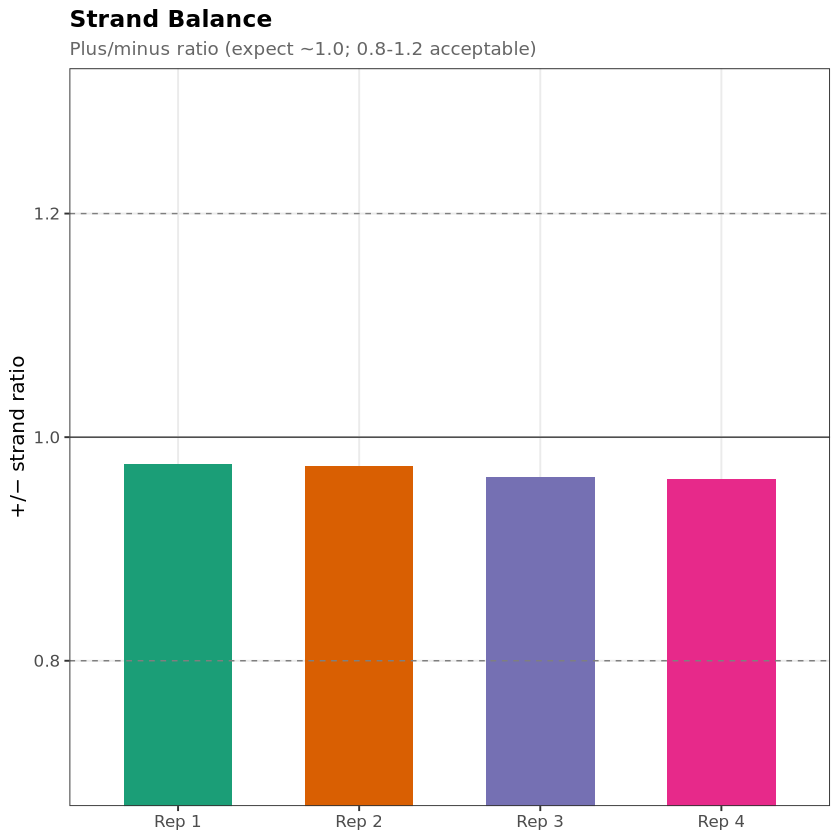

In [33]:
# ==============================================================================
# CELL 5 (FIXED): Strand balance
# ==============================================================================
# FIX: Use coord_cartesian() instead of scale_y limits.
# geom_bar draws from y=0, so limits=c(0.7,1.3) was clipping all bars.

# ---- Tunable parameters ----
strand_title     <- "Strand Balance"
strand_subtitle  <- "Plus/minus ratio (expect ~1.0; 0.8-1.2 acceptable)"
strand_ylim      <- c(0.7, 1.3)
strand_ref       <- 1.0
strand_tol       <- c(0.8, 1.2)

# ---- Print check ----
cat("Strand ratios:\n")
print(align[, .(sample, plus_strand, minus_strand, strand_ratio)])

# ---- Plot ----
p_strand <- ggplot(align, aes(x = sample_short, y = strand_ratio, fill = sample)) +
    geom_bar(stat = "identity", width = 0.6) +
    geom_hline(yintercept = strand_ref, linetype = "solid", color = "black",
               linewidth = 0.3) +
    geom_hline(yintercept = strand_tol, linetype = "dashed", color = "grey50",
               linewidth = 0.4) +
    scale_fill_manual(values = SAMPLE_COLORS, guide = "none") +
    coord_cartesian(ylim = strand_ylim) +
    labs(title    = strand_title,
         subtitle = strand_subtitle,
         x = NULL, y = "+/\u2212 strand ratio") +
    THEME

print(p_strand)

# ---- Save ----
plots <- list("08_strand_balance" = p_strand)
for (nm in names(plots)) {
    fpath <- file.path(PLOT_DIR, paste0(nm, ".png"))
    ggsave(fpath, plot = plots[[nm]], width = 6, height = 4, dpi = PNG_DPI)
    cat(sprintf("  [SAVED] %s\n", fpath))
}




WASP stacked bar sanity check:
           sample input_reads total_check  diff
           <char>       <int>       <int> <int>
1: WT_PROseq_rep1    35137440    35136215  1225
2: WT_PROseq_rep2    39993943    39992540  1403
3: WT_PROseq_rep3    32790956    32789650  1306
4: WT_PROseq_rep4    26789003    26788077   926

WASP filtering per sample:
  WT_PROseq_rep1: 35,137,440 input -> 34,627,822 final (1.45% removed)
  WT_PROseq_rep2: 39,993,943 input -> 39,409,701 final (1.46% removed)
  WT_PROseq_rep3: 32,790,956 input -> 32,310,059 final (1.47% removed)
  WT_PROseq_rep4: 26,789,003 input -> 26,393,166 final (1.48% removed)
[SAVED] 10_wasp_filtering.png
[SAVED] 10_wasp_filtering_legend.png


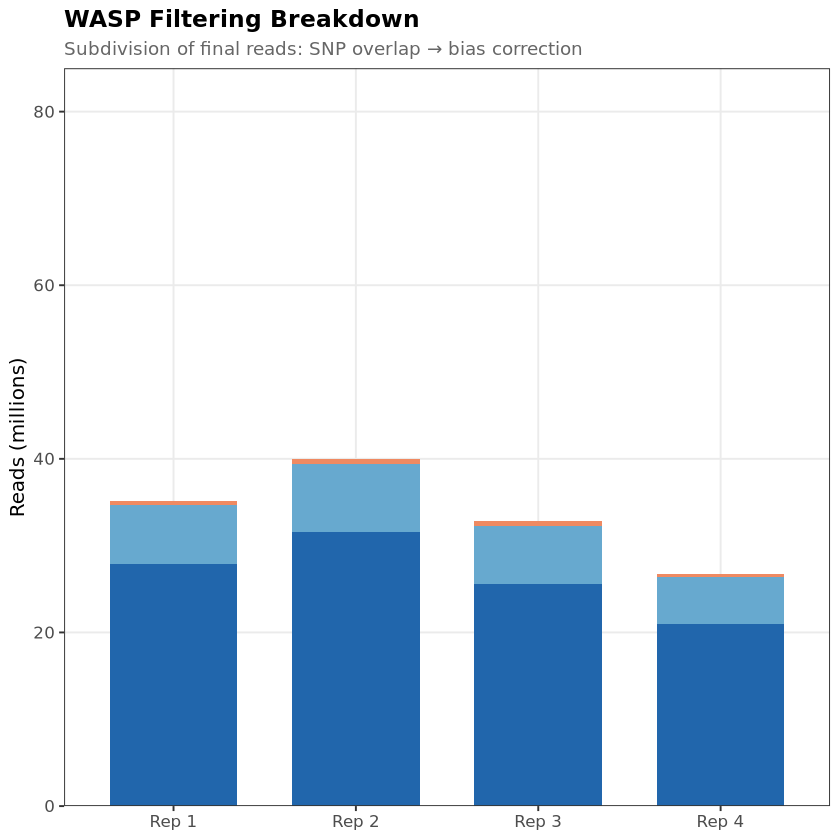

In [ ]:
# ==============================================================================
# CELL 6 (FIXED): WASP filtering — reversed stack, same y-max = 85
# ==============================================================================

# ---- Tunable parameters ----
wasp_stacked_title    <- "WASP Filtering Breakdown"
wasp_stacked_subtitle <- "Subdivision of final reads: SNP overlap \u2192 bias correction"
wasp_bar_width        <- 0.7

# ---- WASP-specific colors ----
WASP_COLORS <- c(
    "Kept (no SNP overlap)"   = "#2166ac",
    "Kept (passed WASP)"      = "#67a9cf",
    "Removed (mapping bias)"  = "#ef8a62"
)

# ---- Build WASP stacked data ----
wasp[, sample_short := SHORT_LABELS[sample]]

wasp_stack <- data.table(
    sample       = wasp$sample,
    sample_short = SHORT_LABELS[wasp$sample],
    no_snp       = wasp$no_snp_reads,
    snp_passed   = wasp$snp_passed_wasp,
    snp_removed  = wasp$snp_removed
)

wasp_stack[, total_check := no_snp + snp_passed + snp_removed]
cat("WASP stacked bar sanity check:\n")
print(data.table(sample = wasp$sample,
                 input_reads = wasp$input_reads,
                 total_check = wasp_stack$total_check,
                 diff = wasp$input_reads - wasp_stack$total_check))

wasp_long <- melt(wasp_stack,
    id.vars      = c("sample", "sample_short"),
    measure.vars = c("no_snp", "snp_passed", "snp_removed"),
    variable.name = "category",
    value.name    = "reads"
)

wasp_long[, category_label := fcase(
    category == "no_snp",      "Kept (no SNP overlap)",
    category == "snp_passed",  "Kept (passed WASP)",
    category == "snp_removed", "Removed (mapping bias)"
)]

# REVERSED: "Kept (no SNP)" on TOP, "Removed" at BOTTOM.
WASP_STACK_BOTTOM_TO_TOP <- c(
    "Removed (mapping bias)",
    "Kept (passed WASP)",
    "Kept (no SNP overlap)"
)

wasp_long[, category_label := factor(category_label,
    levels = WASP_STACK_BOTTOM_TO_TOP)]

cat("\nWASP filtering per sample:\n")
for (i in seq_len(nrow(wasp))) {
    cat(sprintf("  %s: %s input -> %s final (%.2f%% removed)\n",
                wasp$sample[i],
                format(wasp$input_reads[i], big.mark = ","),
                format(wasp$final_reads[i], big.mark = ","),
                wasp$total_removed_pct[i]))
}

# ---- Bar plot (no legend, same y-axis as cascade) ----
p_wasp_stacked <- ggplot(wasp_long, aes(x = sample_short, y = reads / 1e6,
                                          fill = category_label)) +
    geom_bar(stat = "identity", width = wasp_bar_width) +
    scale_fill_manual(values = WASP_COLORS, name = "Category") +
    scale_y_continuous(limits = c(0, SHARED_YMAX),
                       expand = expansion(mult = c(0, 0))) +
    labs(title    = wasp_stacked_title,
         subtitle = wasp_stacked_subtitle,
         x = NULL, y = "Reads (millions)") +
    THEME +
    theme(legend.position = "none")

print(p_wasp_stacked)

# ---- Extract and save legend separately ----
p_wasp_with_legend <- p_wasp_stacked +
    theme(legend.position = "right") +
    guides(fill = guide_legend(
        title = "Category",
        title.position = "top"
    ))

wasp_legend <- get_legend(p_wasp_with_legend)
p_wasp_legend_only <- ggdraw(wasp_legend)

# ---- Save ----
ggsave(file.path(PLOT_DIR, "10_wasp_filtering.png"),
       plot = p_wasp_stacked,
       width = PAIRED_PLOT_WIDTH, height = PAIRED_PLOT_HEIGHT, dpi = PNG_DPI)
cat("[SAVED] 10_wasp_filtering.png\n")

ggsave(file.path(PLOT_DIR, "10_wasp_filtering_legend.png"),
       plot = p_wasp_legend_only,
       width = 2.5, height = 1.8, dpi = PNG_DPI, bg = "white")
cat("[SAVED] 10_wasp_filtering_legend.png\n")


Per-SNP allelic depth summary:
  Total SNPs in file:      3,565,567
  SNPs with >=1 read:      3,562,079
  Median depth:            3

  Cumulative counts:
    ≥1 reads: 3,562,079 SNPs
    ≥5 reads: 1,380,414 SNPs
    ≥10 reads:   670,600 SNPs
    ≥20 reads:   273,983 SNPs
    ≥50 reads:    77,606 SNPs


Warning message in annotate("label", x = ifelse(is.null(cov_xmax), max(plot_data$total_allelic) * :
“Ignoring unknown parameters: `label.size`”


[SAVED] 11_wasp_snp_cumulative_plot.png


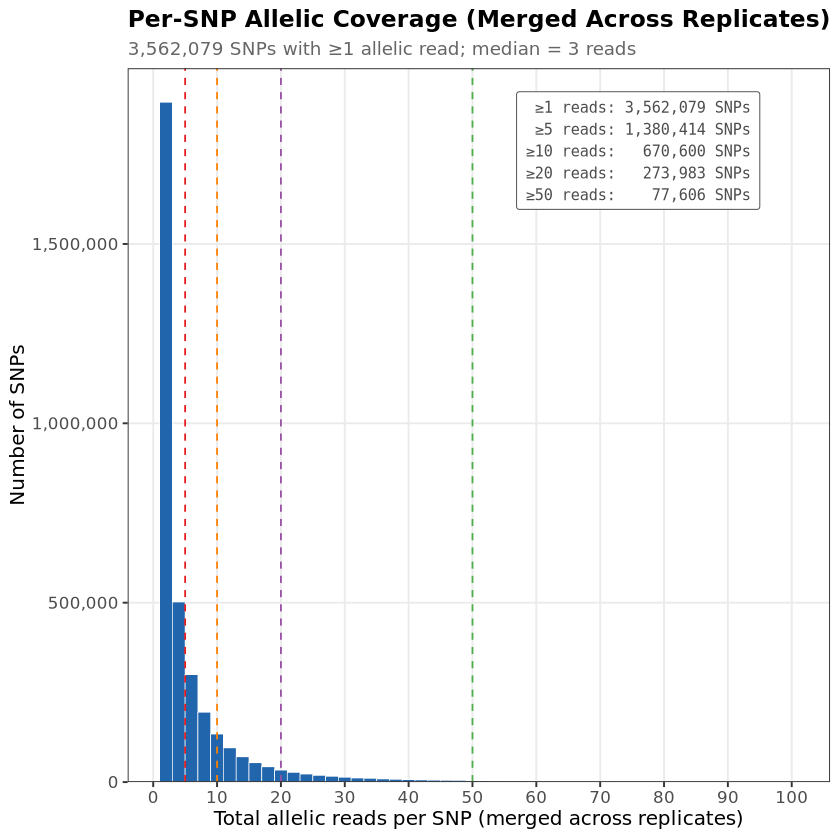

In [46]:
# ==============================================================================
# CELL 7: Per-SNP allelic read depth (with cumulative-count legend box)
# ==============================================================================

# ---- Tunable parameters ----
cov_title       <- "Per-SNP Allelic Coverage (Merged Across Replicates)"
cov_subtitle    <- NULL   # auto-generated below
cov_xmax        <- 100    # truncate x-axis (set NULL for full range)
cov_binwidth    <- 2
cov_thresholds  <- c(1, 5, 10, 20, 50)   # cumulative count thresholds
cov_use_log     <- FALSE  # TRUE for log-scale x-axis

# ---- Build data ----
allele_counts[, total_allelic := ref_total + alt_total]
cov_df <- allele_counts[total_allelic > 0]

total_snps   <- nrow(allele_counts)
covered_snps <- nrow(cov_df)
median_depth <- median(cov_df$total_allelic)

# ---- Compute cumulative counts ----
cum_counts <- data.table(
    threshold = cov_thresholds,
    n_snps    = sapply(cov_thresholds, function(t) sum(cov_df$total_allelic >= t))
)
cum_counts[, label := sprintf("\u2265%d reads: %s SNPs",
                               threshold, format(n_snps, big.mark = ","))]

cat("Per-SNP allelic depth summary:\n")
cat(sprintf("  Total SNPs in file:      %s\n", format(total_snps, big.mark = ",")))
cat(sprintf("  SNPs with >=1 read:      %s\n", format(covered_snps, big.mark = ",")))
cat(sprintf("  Median depth:            %d\n", median_depth))
cat("\n  Cumulative counts:\n")
for (i in seq_len(nrow(cum_counts))) {
    cat(sprintf("    %s\n", cum_counts$label[i]))
}

# Auto-generate subtitle
cov_subtitle <- paste0(
    format(covered_snps, big.mark = ","), " SNPs with \u22651 allelic read; ",
    "median = ", median_depth, " reads"
)

# ---- Build annotation box text ----
box_text <- paste0(
    #"Total SNPs: ", format(total_snps, big.mark = ","), "\n",
    paste(cum_counts$label, collapse = "\n")
)

# ---- Plot ----
plot_data <- if (!is.null(cov_xmax)) cov_df[total_allelic <= cov_xmax] else cov_df

if (cov_use_log) {
    p_snp_depth <- ggplot(cov_df, aes(x = total_allelic)) +
        geom_histogram(bins = 80, fill = "#2166ac", color = "white",
                       linewidth = 0.2) +
        scale_x_log10(labels = comma) +
        scale_y_continuous(labels = comma,
                           expand = expansion(mult = c(0, 0.05))) +
        labs(title    = cov_title,
             subtitle = cov_subtitle,
             x = "Total allelic reads per SNP (log scale)",
             y = "Number of SNPs") +
        THEME
} else {
    p_snp_depth <- ggplot(plot_data, aes(x = total_allelic)) +
        geom_histogram(binwidth = cov_binwidth, fill = "#2166ac",
                       color = "white", linewidth = 0.2) +
        scale_x_continuous(
            breaks = seq(0, ifelse(is.null(cov_xmax),
                                   max(plot_data$total_allelic), cov_xmax),
                         by = 10)
        ) +
        scale_y_continuous(labels = comma,
                           expand = expansion(mult = c(0, 0.05))) +
        labs(title    = cov_title,
             subtitle = cov_subtitle,
             x = "Total allelic reads per SNP (merged across replicates)",
             y = "Number of SNPs") +
        THEME
}

# Add cumulative-count annotation box (top-right corner)
p_snp_depth <- p_snp_depth +
    annotate("label",
             x = ifelse(is.null(cov_xmax),
                        max(plot_data$total_allelic) * 0.95,
                        cov_xmax * 0.95),
             y = Inf,
             label    = box_text,
             hjust    = 1,
             vjust    = 1.2,
             size     = 3.2,
             fill     = "white",
             color    = "grey30",
             label.size    = 0.3,
             label.padding = unit(0.5, "lines"),
             family   = "mono")

# Add dashed vertical lines at thresholds (skip >=1, it's trivial)
thr_in_range <- cov_thresholds[cov_thresholds > 1]
if (!is.null(cov_xmax)) thr_in_range <- thr_in_range[thr_in_range <= cov_xmax]

thr_colors <- c("#e41a1c", "#ff7f00", "#984ea3", "#4daf4a", "#377eb8")
for (k in seq_along(thr_in_range)) {
    p_snp_depth <- p_snp_depth +
        geom_vline(xintercept = thr_in_range[k], linetype = "dashed",
                   color = thr_colors[min(k, length(thr_colors))],
                   linewidth = 0.5)
}

print(p_snp_depth)

# ---- Save ----
ggsave(file.path(PLOT_DIR, "11_wasp_snp_cumulative_plot.png"),
       plot = p_snp_depth,
       width = 7, height = 5, dpi = PNG_DPI)
cat("[SAVED] 11_wasp_snp_cumulative_plot.png\n")



Loaded 3,565,567 SNPs from merged counts file.
Per-replicate columns found for: WT_PROseq_rep1, WT_PROseq_rep2, WT_PROseq_rep3, WT_PROseq_rep4

Global allele balance:
          sample      ref      alt    total  ref_frac
1 WT_PROseq_rep1  4350114  3706569  8056683 0.5399386
2 WT_PROseq_rep2  5074355  4309891  9384246 0.5407312
3 WT_PROseq_rep3  4338940  3708244  8047184 0.5391874
4 WT_PROseq_rep4  3466177  2964650  6430827 0.5389940
5         Merged 17229586 14689354 31918940 0.5397919

(ref_frac should be ~0.50 if WASP successfully removed mapping bias)
[SAVED] 12_wasp_allele_balance_plot.png


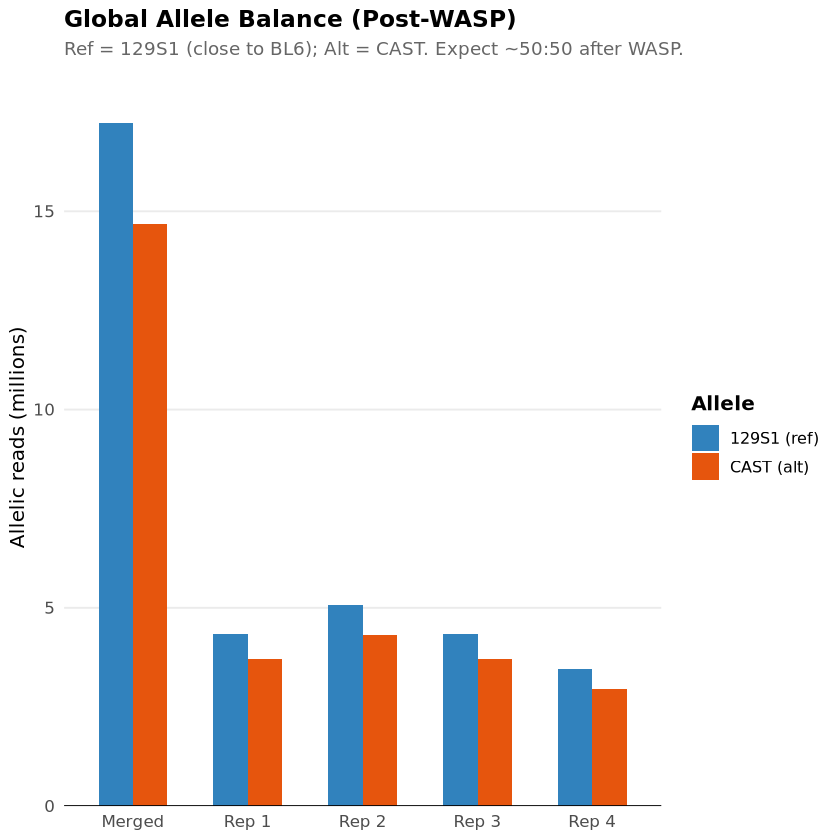

In [47]:
# ==============================================================================
# CELL 7: Global allele balance (ref vs alt reads across all SNPs)
# ==============================================================================

# ---- Plot parameters ----
allele_bar_title    <- "Global Allele Balance (Post-WASP)"
allele_bar_subtitle <- "Ref = 129S1 (close to BL6); Alt = CAST. Expect ~50:50 after WASP."

# ---- Load merged counts ----
counts_df <- read.delim(MERGED_COUNTS_FILE, stringsAsFactors = FALSE)
cat(sprintf("Loaded %s SNPs from merged counts file.\n", format(nrow(counts_df), big.mark = ",")))

# Identify per-rep columns
rep_cols <- grep("_ref$|_alt$", colnames(counts_df), value = TRUE)
rep_samples <- unique(sub("_(ref|alt)$", "", rep_cols))
cat(sprintf("Per-replicate columns found for: %s\n", paste(rep_samples, collapse = ", ")))

# ---- Global balance per replicate ----
global_allele <- data.frame(sample = character(), ref = numeric(),
                            alt = numeric(), stringsAsFactors = FALSE)
for (s in rep_samples) {
    ref_col <- paste0(s, "_ref")
    alt_col <- paste0(s, "_alt")
    if (ref_col %in% colnames(counts_df) & alt_col %in% colnames(counts_df)) {
        global_allele <- rbind(global_allele, data.frame(
            sample = s,
            ref = sum(counts_df[[ref_col]]),
            alt = sum(counts_df[[alt_col]])
        ))
    }
}
# Add merged totals
global_allele <- rbind(global_allele, data.frame(
    sample = "Merged",
    ref = sum(counts_df$ref_total),
    alt = sum(counts_df$alt_total)
))
global_allele <- global_allele %>%
    mutate(
        total = ref + alt,
        ref_frac = ref / total,
        label = ifelse(sample == "Merged", "Merged",
                        SAMPLE_LABELS[sample])
    )

cat("\nGlobal allele balance:\n")
print(global_allele %>% select(sample, ref, alt, total, ref_frac))
cat("\n(ref_frac should be ~0.50 if WASP successfully removed mapping bias)\n")

# ---- Plot ----
allele_long <- global_allele %>%
    pivot_longer(cols = c(ref, alt), names_to = "allele", values_to = "reads") %>%
    mutate(allele = factor(allele, levels = c("ref", "alt"),
                           labels = c("129S1 (ref)", "CAST (alt)")))

p_allele_bar <- ggplot(allele_long,
                        aes(x = label, y = reads / 1e6, fill = allele)) +
    geom_col(position = "dodge", width = 0.6) +
    geom_hline(yintercept = 0) +
    scale_fill_manual(values = c("129S1 (ref)" = "#3182bd", "CAST (alt)" = "#e6550d")) +
    scale_y_continuous(labels = comma_format(), expand = expansion(mult = c(0, 0.08))) +
    labs(
        title    = allele_bar_title,
        subtitle = allele_bar_subtitle,
        x = NULL, y = "Allelic reads (millions)",
        fill = "Allele"
    ) +
    theme_qc()

print(p_allele_bar)

# ---- Save ----
ggsave(file.path(PLOT_DIR, "12_wasp_allele_balance_plot.png"),
       plot = p_allele_bar,
       width = 7, height = 5, dpi = PNG_DPI)
cat("[SAVED] 12_wasp_allele_balance_plot.png\n")


1. REF FRACTION BY DEPTH CUTOFF
   (Higher depth = more precise per-SNP estimate)

  Depth >= 5:  N = 1,380,414 SNPs
    Mean:   0.5428    Median: 0.5479    SD: 0.2852
    Q25:    0.3333    Q75:    0.7647    Skewness: -0.1057
    Mean - 0.5 = 0.0428  (positive = ref-biased)

  Depth >= 10:  N = 670,600 SNPs
    Mean:   0.5378    Median: 0.5343    SD: 0.2330
    Q25:    0.3846    Q75:    0.7000    Skewness: -0.0257
    Mean - 0.5 = 0.0378  (positive = ref-biased)

  Depth >= 20:  N = 273,983 SNPs
    Mean:   0.5345    Median: 0.5275    SD: 0.1947
    Q25:    0.4118    Q75:    0.6522    Skewness: 0.0684
    Mean - 0.5 = 0.0345  (positive = ref-biased)

  Depth >= 50:  N = 77,606 SNPs
    Mean:   0.5345    Median: 0.5238    SD: 0.1688
    Q25:    0.4381    Q75:    0.6203    Skewness: 0.2293
    Mean - 0.5 = 0.0345  (positive = ref-biased)

  Depth >= 100:  N = 31,358 SNPs
    Mean:   0.5357    Median: 0.5228    SD: 0.1573
    Q25:    0.4497    Q75:    0.6058    Skewness: 0.3558
    Mean -

Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_bar()`).”


[SAVED] 15b_ref_fraction_stratified.png


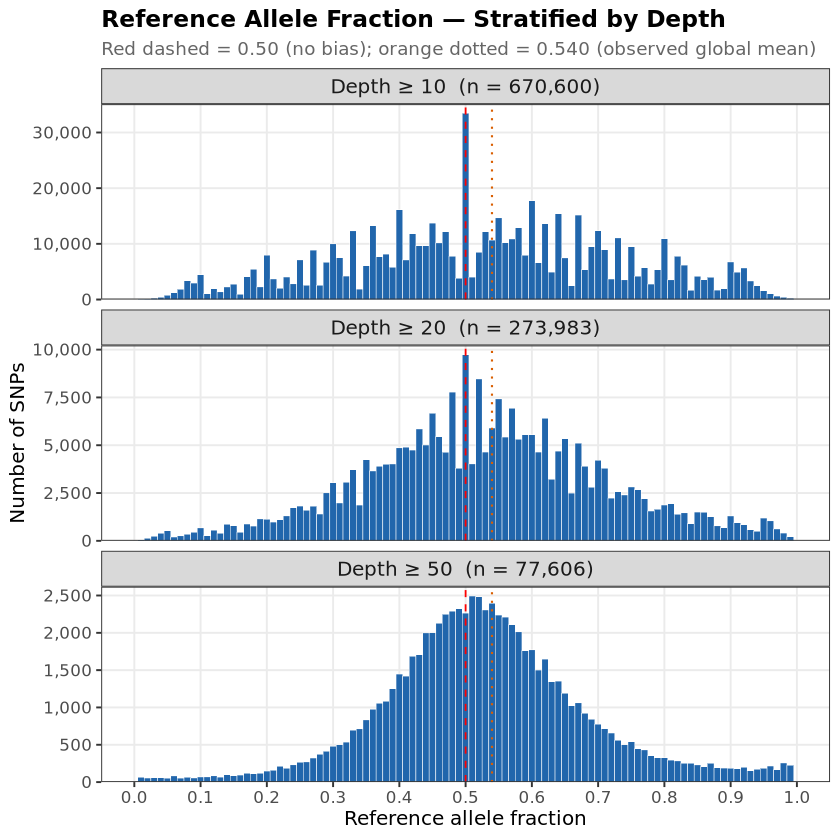

In [48]:
# ==============================================================================
# CELL 8b: Ref-fraction diagnostics — is the ~54% bias uniform or localized?
# ==============================================================================

library(data.table)
library(ggplot2)
library(scales)

# ---- Tunable parameters ----
depth_cutoffs <- c(5, 10, 20, 50, 100)   # analyze ref fraction at each cutoff
extreme_threshold <- 0.05                  # flag SNPs with ref_frac < this or > 1-this

# ---- Ensure total_allelic and ref_frac_num exist ----
allele_counts[, total_allelic := ref_total + alt_total]
allele_counts[, ref_frac_num := fifelse(total_allelic > 0,
                                         ref_total / total_allelic, NA_real_)]

# ==========================================================================
# 1. Ref fraction stratified by depth
# ==========================================================================
cat("=" |> rep(70) |> paste(collapse = ""), "\n")
cat("1. REF FRACTION BY DEPTH CUTOFF\n")
cat("   (Higher depth = more precise per-SNP estimate)\n")
cat("=" |> rep(70) |> paste(collapse = ""), "\n\n")

for (d in depth_cutoffs) {
    sub <- allele_counts[total_allelic >= d & !is.na(ref_frac_num)]
    n <- nrow(sub)
    mn <- mean(sub$ref_frac_num)
    md <- median(sub$ref_frac_num)
    sd_val <- sd(sub$ref_frac_num)
    q25 <- quantile(sub$ref_frac_num, 0.25)
    q75 <- quantile(sub$ref_frac_num, 0.75)
    skew <- mean(((sub$ref_frac_num - mn) / sd_val)^3)

    cat(sprintf("  Depth >= %d:  N = %s SNPs\n", d, format(n, big.mark = ",")))
    cat(sprintf("    Mean:   %.4f    Median: %.4f    SD: %.4f\n", mn, md, sd_val))
    cat(sprintf("    Q25:    %.4f    Q75:    %.4f    Skewness: %.4f\n", q25, q75, skew))
    cat(sprintf("    Mean - 0.5 = %.4f  (positive = ref-biased)\n\n", mn - 0.5))
}

# ==========================================================================
# 2. Formal binomial test: is the global ref count significantly > 50%?
# ==========================================================================
cat("=" |> rep(70) |> paste(collapse = ""), "\n")
cat("2. BINOMIAL TEST: global ref fraction vs 0.50\n")
cat("=" |> rep(70) |> paste(collapse = ""), "\n\n")

total_ref <- sum(allele_counts$ref_total)
total_alt <- sum(allele_counts$alt_total)
total_all <- total_ref + total_alt
global_frac <- total_ref / total_all

bt <- binom.test(total_ref, total_all, p = 0.5)
cat(sprintf("  Total ref reads:  %s\n", format(total_ref, big.mark = ",")))
cat(sprintf("  Total alt reads:  %s\n", format(total_alt, big.mark = ",")))
cat(sprintf("  Global ref frac:  %.6f\n", global_frac))
cat(sprintf("  Binomial p-value: %s (vs H0: p = 0.5)\n", format.pval(bt$p.value)))
cat(sprintf("  95%% CI:           [%.6f, %.6f]\n\n", bt$conf.int[1], bt$conf.int[2]))
cat("  NOTE: With ~32M reads the test has enormous power, so even tiny\n")
cat("  deviations from 0.5 are 'significant'. What matters is the EFFECT\n")
cat("  SIZE (0.54 vs 0.50), not the p-value.\n\n")

# ==========================================================================
# 3. Per-SNP binomial test (well-covered SNPs): how many are individually biased?
# ==========================================================================
cat("=" |> rep(70) |> paste(collapse = ""), "\n")
cat("3. PER-SNP BINOMIAL TESTS (depth >= 20)\n")
cat("   Testing each SNP individually vs p = 0.5\n")
cat("=" |> rep(70) |> paste(collapse = ""), "\n\n")

well_covered <- allele_counts[total_allelic >= 20]
cat(sprintf("  SNPs with depth >= 20: %s\n", format(nrow(well_covered), big.mark = ",")))

# Run per-SNP binomial test (fast vectorized approximation using normal approx)
well_covered[, z_score := (ref_total - total_allelic * 0.5) /
                           sqrt(total_allelic * 0.25)]
well_covered[, p_value := 2 * pnorm(-abs(z_score))]
well_covered[, p_adj := p.adjust(p_value, method = "BH")]

n_sig_nominal <- sum(well_covered$p_value < 0.05)
n_sig_bh      <- sum(well_covered$p_adj < 0.05)
n_ref_biased  <- sum(well_covered$p_adj < 0.05 & well_covered$ref_frac_num > 0.5)
n_alt_biased  <- sum(well_covered$p_adj < 0.05 & well_covered$ref_frac_num < 0.5)

cat(sprintf("  Significant at nominal p < 0.05:     %s (%.1f%%)\n",
            format(n_sig_nominal, big.mark = ","),
            100 * n_sig_nominal / nrow(well_covered)))
cat(sprintf("  Significant at BH-adjusted p < 0.05: %s (%.1f%%)\n",
            format(n_sig_bh, big.mark = ","),
            100 * n_sig_bh / nrow(well_covered)))
cat(sprintf("    Of which ref-biased (>0.5):  %s\n", format(n_ref_biased, big.mark = ",")))
cat(sprintf("    Of which alt-biased (<0.5):  %s\n", format(n_alt_biased, big.mark = ",")))
cat(sprintf("    Ratio ref-biased / alt-biased: %.2f\n\n",
            n_ref_biased / max(n_alt_biased, 1)))
cat("  If ratio >> 1, the residual bias is genome-wide (favoring ref).\n")
cat("  If ratio ~ 1, there's no systematic direction.\n\n")

# ==========================================================================
# 4. Extreme-bias SNPs
# ==========================================================================
cat("=" |> rep(70) |> paste(collapse = ""), "\n")
cat("4. EXTREME BIAS SNPs (ref_frac < 0.05 or > 0.95, depth >= 20)\n")
cat("=" |> rep(70) |> paste(collapse = ""), "\n\n")

extreme_ref <- well_covered[ref_frac_num > (1 - extreme_threshold)]
extreme_alt <- well_covered[ref_frac_num < extreme_threshold]

cat(sprintf("  Extreme ref-biased (>%.0f%% ref): %s SNPs\n",
            100 * (1 - extreme_threshold),
            format(nrow(extreme_ref), big.mark = ",")))
cat(sprintf("  Extreme alt-biased (>%.0f%% alt): %s SNPs\n",
            100 * (1 - extreme_threshold),
            format(nrow(extreme_alt), big.mark = ",")))
cat(sprintf("  Total extreme:                %s (%.2f%% of depth>=20 SNPs)\n\n",
            format(nrow(extreme_ref) + nrow(extreme_alt), big.mark = ","),
            100 * (nrow(extreme_ref) + nrow(extreme_alt)) / nrow(well_covered)))

# ==========================================================================
# 5. Compare observed distribution to expected binomial at p = 0.54
# ==========================================================================
cat("=" |> rep(70) |> paste(collapse = ""), "\n")
cat("5. IS THE SHIFT UNIFORM? Comparing to binomial(p=0.54) expectation\n")
cat("=" |> rep(70) |> paste(collapse = ""), "\n\n")

# For well-covered SNPs, compute expected SD under binomial(n, p=0.54)
# and compare to observed SD
well_covered[, expected_sd := sqrt(0.54 * 0.46 / total_allelic)]
well_covered[, z_vs_054 := (ref_frac_num - 0.54) / expected_sd]

mean_z <- mean(well_covered$z_vs_054)
sd_z   <- sd(well_covered$z_vs_054)

cat(sprintf("  If bias is purely uniform p=0.54 + binomial noise:\n"))
cat(sprintf("    Expected z-scores: mean=0, sd=1\n"))
cat(sprintf("    Observed z-scores: mean=%.4f, sd=%.4f\n\n", mean_z, sd_z))
cat(sprintf("  Interpretation:\n"))
cat(sprintf("    mean ~ 0:  The 0.54 estimate is correct on average\n"))
cat(sprintf("    sd ~ 1:    Variation is JUST binomial noise (uniform bias)\n"))
cat(sprintf("    sd >> 1:   Extra variation beyond binomial = locus-specific bias\n"))
cat(sprintf("    sd ~ %.2f: %s\n\n",
            sd_z,
            ifelse(sd_z < 1.2, "Mostly uniform — binomial noise dominates",
            ifelse(sd_z < 2.0, "Some locus-specific effects on top of uniform bias",
                               "Substantial locus-specific bias"))))

# ==========================================================================
# 6. IMPROVED PLOT: ref fraction at multiple depth cutoffs
# ==========================================================================
cat("Generating stratified ref-fraction plot...\n")

# Build stratified data for faceted plot
strat_list <- list()
for (d in c(10, 20, 50)) {
    sub <- allele_counts[total_allelic >= d & !is.na(ref_frac_num)]
    sub_plot <- data.table(
        ref_frac = sub$ref_frac_num,
        depth_label = sprintf("Depth \u2265 %d  (n = %s)", d,
                               format(nrow(sub), big.mark = ","))
    )
    strat_list <- c(strat_list, list(sub_plot))
}
strat_df <- rbindlist(strat_list)

# Order facets by increasing depth
strat_df[, depth_label := factor(depth_label, levels = unique(depth_label))]

p_reffrac_strat <- ggplot(strat_df, aes(x = ref_frac)) +
    geom_histogram(binwidth = 0.01, fill = "#2166ac",
                   color = "white", linewidth = 0.15) +
    geom_vline(xintercept = 0.5, linetype = "dashed", color = "red",
               linewidth = 0.5) +
    geom_vline(xintercept = global_frac, linetype = "dotted", color = "#d95f02",
               linewidth = 0.6) +
    facet_wrap(~ depth_label, ncol = 1, scales = "free_y") +
    scale_x_continuous(breaks = seq(0, 1, by = 0.1), limits = c(0, 1)) +
    scale_y_continuous(labels = comma,
                       expand = expansion(mult = c(0, 0.05))) +
    labs(title    = "Reference Allele Fraction — Stratified by Depth",
         subtitle = sprintf(
             "Red dashed = 0.50 (no bias); orange dotted = %.3f (observed global mean)",
             global_frac),
         x = "Reference allele fraction",
         y = "Number of SNPs") +
    THEME

print(p_reffrac_strat)

ggsave(file.path(PLOT_DIR, "15b_ref_fraction_stratified.png"),
       plot = p_reffrac_strat,
       width = 8, height = 8, dpi = PNG_DPI)
cat("[SAVED] 15b_ref_fraction_stratified.png\n")

In [49]:
# ==============================================================================
# CELL 8c: Ref-fraction diagnostics — publication-ready tables & plots
# ==============================================================================
# Generates:
#   16a_reffrac_summary_table.png     — stratified ref-fraction stats
#   16b_reffrac_bias_direction.png    — ref-biased vs alt-biased SNP counts
#   16c_reffrac_overdispersion.png    — z-score distribution vs binomial expectation
#   16d_reffrac_extreme_snps.png      — extreme-bias SNP summary
#   16e_reffrac_replicate_table.png   — per-replicate global ref fraction
# ==============================================================================

library(data.table)
library(ggplot2)
library(scales)
library(grid)
library(gridExtra)

# ---- Ensure columns exist ----
allele_counts[, total_allelic := ref_total + alt_total]
allele_counts[, ref_frac_num := fifelse(total_allelic > 0,
                                         ref_total / total_allelic, NA_real_)]

total_ref <- sum(allele_counts$ref_total)
total_alt <- sum(allele_counts$alt_total)
total_all <- total_ref + total_alt
global_frac <- total_ref / total_all

# ==========================================================================
# TABLE 1: Ref fraction by depth cutoff
# ==========================================================================

depth_cutoffs <- c(5, 10, 20, 50, 100)
tbl1_rows <- list()
for (d in depth_cutoffs) {
    sub <- allele_counts[total_allelic >= d & !is.na(ref_frac_num)]
    tbl1_rows[[length(tbl1_rows) + 1]] <- data.table(
        `Min Depth` = d,
        `N SNPs`    = format(nrow(sub), big.mark = ","),
        Mean        = sprintf("%.4f", mean(sub$ref_frac_num)),
        Median      = sprintf("%.4f", median(sub$ref_frac_num)),
        SD          = sprintf("%.4f", sd(sub$ref_frac_num)),
        `Bias (mean − 0.5)` = sprintf("+%.4f", mean(sub$ref_frac_num) - 0.5)
    )
}
tbl1 <- rbindlist(tbl1_rows)

tt1 <- tableGrob(tbl1,
    rows  = NULL,
    theme = ttheme_minimal(
        core    = list(fg_params = list(fontsize = 11, hjust = 0.5),
                       bg_params = list(fill = c("grey95", "white"))),
        colhead = list(fg_params = list(fontsize = 12, fontface = "bold"),
                       bg_params = list(fill = "#2166ac"),
                       fg_params = list(col = "white", fontsize = 12,
                                        fontface = "bold"))
    )
)

p_tbl1 <- ggplot() +
    annotation_custom(tt1) +
    labs(title    = "Ref Allele Fraction by Minimum Depth Cutoff",
         subtitle = "Bias is stable at ~+0.035 across all depth thresholds (ref = 129S1/BL6)") +
    theme_void() +
    theme(plot.title    = element_text(size = 14, face = "bold", hjust = 0,
                                        margin = margin(b = 5)),
          plot.subtitle = element_text(size = 11, color = "grey40", hjust = 0,
                                        margin = margin(b = 10)),
          plot.margin   = margin(15, 15, 15, 15))

ggsave(file.path(PLOT_DIR, "16a_reffrac_summary_table.png"),
       plot = p_tbl1, width = 8, height = 3.5, dpi = PNG_DPI, bg = "white")
cat("[SAVED] 16a_reffrac_summary_table.png\n")

# ==========================================================================
# PLOT 2: Ref-biased vs alt-biased SNPs (horizontal bar)
# ==========================================================================

well_covered <- allele_counts[total_allelic >= 20]
well_covered[, z_score := (ref_total - total_allelic * 0.5) /
                           sqrt(total_allelic * 0.25)]
well_covered[, p_value := 2 * pnorm(-abs(z_score))]
well_covered[, p_adj := p.adjust(p_value, method = "BH")]

n_total_wc   <- nrow(well_covered)
n_sig_bh     <- sum(well_covered$p_adj < 0.05)
n_ref_biased <- sum(well_covered$p_adj < 0.05 & well_covered$ref_frac_num > 0.5)
n_alt_biased <- sum(well_covered$p_adj < 0.05 & well_covered$ref_frac_num < 0.5)
n_not_sig    <- n_total_wc - n_sig_bh

bias_df <- data.table(
    category = factor(
        c("Ref-biased (129S1)", "Alt-biased (CAST)", "Not significant"),
        levels = c("Not significant", "Alt-biased (CAST)", "Ref-biased (129S1)")
    ),
    count = c(n_ref_biased, n_alt_biased, n_not_sig),
    color = c("#2166ac", "#b2182b", "grey70")
)
bias_df[, pct := sprintf("%.1f%%", 100 * count / n_total_wc)]
bias_df[, label := sprintf("%s  (%s)", format(count, big.mark = ","), pct)]

p_bias <- ggplot(bias_df, aes(x = category, y = count / 1000, fill = category)) +
    geom_bar(stat = "identity", width = 0.6) +
    geom_text(aes(label = label), hjust = -0.05, size = 4) +
    scale_fill_manual(values = c(
        "Ref-biased (129S1)" = "#2166ac",
        "Alt-biased (CAST)"  = "#b2182b",
        "Not significant"    = "grey70"
    ), guide = "none") +
    scale_y_continuous(expand = expansion(mult = c(0, 0.35))) +
    coord_flip() +
    labs(title    = "Per-SNP Allelic Bias Direction (BH-adjusted p < 0.05)",
         subtitle = sprintf(
             "N = %s SNPs with depth \u2265 20; ref:alt biased ratio = %.2f",
             format(n_total_wc, big.mark = ","),
             n_ref_biased / max(n_alt_biased, 1)),
         x = NULL, y = "SNPs (thousands)") +
    THEME +
    theme(axis.text.y = element_text(size = 12))

ggsave(file.path(PLOT_DIR, "16b_reffrac_bias_direction.png"),
       plot = p_bias, width = 8, height = 3.5, dpi = PNG_DPI, bg = "white")
cat("[SAVED] 16b_reffrac_bias_direction.png\n")

# ==========================================================================
# PLOT 3: Z-score distribution vs standard normal (overdispersion test)
# ==========================================================================

well_covered[, z_vs_054 := (ref_frac_num - global_frac) /
                            sqrt(global_frac * (1 - global_frac) / total_allelic)]

obs_sd <- sd(well_covered$z_vs_054)
obs_mn <- mean(well_covered$z_vs_054)

# Subsample for plotting speed
set.seed(42)
plot_z <- well_covered[sample(.N, min(.N, 100000))]

p_overdisp <- ggplot(plot_z, aes(x = z_vs_054)) +
    geom_histogram(aes(y = after_stat(density)), binwidth = 0.1,
                   fill = "#2166ac", color = "white", linewidth = 0.15,
                   alpha = 0.7) +
    stat_function(fun = dnorm, args = list(mean = 0, sd = 1),
                  color = "red", linewidth = 1, linetype = "dashed") +
    annotate("label",
             x = max(plot_z$z_vs_054) * 0.7, y = Inf,
             vjust = 1.3, hjust = 0.5, size = 4,
             fill = "white", label.size = 0.3,
             label = paste0(
                 "Expected (binomial): SD = 1.00\n",
                 "Observed: SD = ", sprintf("%.2f", obs_sd), "\n",
                 "Overdispersion: ", sprintf("%.1f\u00d7", obs_sd)
             )) +
    scale_x_continuous(limits = c(-10, 10)) +
    labs(title    = "Overdispersion Test: Observed vs Expected Z-Scores",
         subtitle = sprintf(
             "Z-scores under H0: binomial(n, p=%.3f). Red dashed = standard normal",
             global_frac),
         x = "Z-score (per-SNP ref fraction vs global mean)",
         y = "Density") +
    THEME

ggsave(file.path(PLOT_DIR, "16c_reffrac_overdispersion.png"),
       plot = p_overdisp, width = 8, height = 5, dpi = PNG_DPI, bg = "white")
cat("[SAVED] 16c_reffrac_overdispersion.png\n")

# ==========================================================================
# TABLE 2: Extreme-bias SNP summary
# ==========================================================================

extreme_cuts <- c(0.05, 0.10, 0.20)
tbl2_rows <- list()
for (ec in extreme_cuts) {
    n_ext_ref <- nrow(well_covered[ref_frac_num > (1 - ec)])
    n_ext_alt <- nrow(well_covered[ref_frac_num < ec])
    n_ext_tot <- n_ext_ref + n_ext_alt
    tbl2_rows[[length(tbl2_rows) + 1]] <- data.table(
        Criterion   = sprintf("ref > %.0f%% or alt > %.0f%%",
                               100 * (1 - ec), 100 * (1 - ec)),
        `Ref-extreme` = format(n_ext_ref, big.mark = ","),
        `Alt-extreme` = format(n_ext_alt, big.mark = ","),
        Total         = format(n_ext_tot, big.mark = ","),
        `% of SNPs`   = sprintf("%.2f%%", 100 * n_ext_tot / n_total_wc),
        `Ref:Alt`     = sprintf("%.2f", n_ext_ref / max(n_ext_alt, 1))
    )
}
tbl2 <- rbindlist(tbl2_rows)

tt2 <- tableGrob(tbl2,
    rows  = NULL,
    theme = ttheme_minimal(
        core    = list(fg_params = list(fontsize = 11, hjust = 0.5),
                       bg_params = list(fill = c("grey95", "white"))),
        colhead = list(fg_params = list(col = "white", fontsize = 12,
                                        fontface = "bold"),
                       bg_params = list(fill = "#2166ac"))
    )
)

p_tbl2 <- ggplot() +
    annotation_custom(tt2) +
    labs(title    = "Extreme Allelic Bias at het SNPs (depth \u2265 20)",
         subtitle = sprintf(
             "N = %s SNPs. Recommend filtering SNPs beyond 95%% threshold before TFBS analysis.",
             format(n_total_wc, big.mark = ","))) +
    theme_void() +
    theme(plot.title    = element_text(size = 14, face = "bold", hjust = 0,
                                        margin = margin(b = 5)),
          plot.subtitle = element_text(size = 11, color = "grey40", hjust = 0,
                                        margin = margin(b = 10)),
          plot.margin   = margin(15, 15, 15, 15))

ggsave(file.path(PLOT_DIR, "16d_reffrac_extreme_table.png"),
       plot = p_tbl2, width = 8, height = 3, dpi = PNG_DPI, bg = "white")
cat("[SAVED] 16d_reffrac_extreme_table.png\n")

# ==========================================================================
# TABLE 3: Per-replicate global ref fraction
# ==========================================================================

counts_df <- as.data.table(allele_counts)
rep_cols <- grep("_ref$|_alt$", colnames(counts_df), value = TRUE)
rep_samples <- unique(sub("_(ref|alt)$", "", rep_cols))

tbl3_rows <- list()
for (s in rep_samples) {
    rc <- paste0(s, "_ref")
    ac <- paste0(s, "_alt")
    if (rc %in% colnames(counts_df) & ac %in% colnames(counts_df)) {
        r <- sum(counts_df[[rc]])
        a <- sum(counts_df[[ac]])
        tot <- r + a
        tbl3_rows[[length(tbl3_rows) + 1]] <- data.table(
            Sample       = SHORT_LABELS[s],
            `Ref reads`  = format(r, big.mark = ","),
            `Alt reads`  = format(a, big.mark = ","),
            Total        = format(tot, big.mark = ","),
            `Ref fraction` = sprintf("%.4f", r / tot),
            `Bias (−0.5)`  = sprintf("+%.4f", r / tot - 0.5)
        )
    }
}
# Add merged row
tbl3_rows[[length(tbl3_rows) + 1]] <- data.table(
    Sample       = "Merged",
    `Ref reads`  = format(total_ref, big.mark = ","),
    `Alt reads`  = format(total_alt, big.mark = ","),
    Total        = format(total_all, big.mark = ","),
    `Ref fraction` = sprintf("%.4f", global_frac),
    `Bias (−0.5)`  = sprintf("+%.4f", global_frac - 0.5)
)
tbl3 <- rbindlist(tbl3_rows)

# Bold the merged row
tt3 <- tableGrob(tbl3,
    rows  = NULL,
    theme = ttheme_minimal(
        core    = list(fg_params = list(fontsize = 11, hjust = 0.5),
                       bg_params = list(fill = c(rep(c("grey95", "white"),
                                                      length(rep_samples) %/% 2 + 1),
                                                  "#e0ecf4")[1:(length(rep_samples) + 1)])),
        colhead = list(fg_params = list(col = "white", fontsize = 12,
                                        fontface = "bold"),
                       bg_params = list(fill = "#2166ac"))
    )
)

p_tbl3 <- ggplot() +
    annotation_custom(tt3) +
    labs(title    = "Per-Replicate Global Allele Balance (Post-WASP)",
         subtitle = "Consistent ~54% ref fraction across all replicates confirms systematic, not stochastic, bias") +
    theme_void() +
    theme(plot.title    = element_text(size = 14, face = "bold", hjust = 0,
                                        margin = margin(b = 5)),
          plot.subtitle = element_text(size = 11, color = "grey40", hjust = 0,
                                        margin = margin(b = 10)),
          plot.margin   = margin(15, 15, 15, 15))

ggsave(file.path(PLOT_DIR, "16e_reffrac_replicate_table.png"),
       plot = p_tbl3, width = 9, height = 3, dpi = PNG_DPI, bg = "white")
cat("[SAVED] 16e_reffrac_replicate_table.png\n")

# ==========================================================================
# Summary printout
# ==========================================================================
cat("\n")
cat("=" |> rep(70) |> paste(collapse = ""), "\n")
cat("SUMMARY FOR PIs\n")
cat("=" |> rep(70) |> paste(collapse = ""), "\n")
cat("1. Global ref fraction: 54.0% (stable across all 4 replicates)\n")
cat("2. Bias is genome-wide and directional (1.8x more ref-biased than alt-biased SNPs)\n")
cat(sprintf("3. Overdispersion SD = %.2f (substantial locus-specific variation)\n", obs_sd))
cat("4. ~4% of well-covered SNPs show extreme bias (>95% one allele)\n")
cat("5. Recommendations:\n")
cat("   - Use beta-binomial (not binomial) model for allele-specific tests\n")
cat("   - Filter extreme-bias SNPs (>95% ref or >95% alt) before TFBS analysis\n")
cat("   - The uniform component (~+3.5%) cancels out in motif-strength comparisons\n")
cat("=" |> rep(70) |> paste(collapse = ""), "\n")


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




[SAVED] 16a_reffrac_summary_table.png
[SAVED] 16b_reffrac_bias_direction.png


Warning message in annotate("label", x = max(plot_z$z_vs_054) * 0.7, y = Inf, vjust = 1.3, :
“Ignoring unknown parameters: `label.size`”
Warning message:
“Removed 615 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_label()`).”


[SAVED] 16c_reffrac_overdispersion.png
[SAVED] 16d_reffrac_extreme_table.png
[SAVED] 16e_reffrac_replicate_table.png

SUMMARY FOR PIs
1. Global ref fraction: 54.0% (stable across all 4 replicates)
2. Bias is genome-wide and directional (1.8x more ref-biased than alt-biased SNPs)
3. Overdispersion SD = 2.73 (substantial locus-specific variation)
4. ~4% of well-covered SNPs show extreme bias (>95% one allele)
5. Recommendations:
   - Use beta-binomial (not binomial) model for allele-specific tests
   - Filter extreme-bias SNPs (>95% ref or >95% alt) before TFBS analysis
   - The uniform component (~+3.5%) cancels out in motif-strength comparisons
